# Motivation

In this project, the main question is: what proportion does each prey group contribute to a predator’s diet? More specifically, this project examines the diet of bottlenose dolphins and asks whether stable isotope data can be used to estimate the contribution of prey groups such as fish and cephalopods. Understanding diet composition can help researchers better understand dolphin trophic ecology, identify where dolphins sit in the food web, evaluate how environmental changes may affect them, and assess whether dolphins may serve as indicators of ecosystem change.

Stable isotope analysis is commonly used to study marine food webs because carbon and nitrogen isotopes provide different ecological information. Carbon isotopes (δ¹³C) change very little between trophic levels, meaning they mostly reflect the original source of primary production at the base of the food web. Because of this, δ¹³C values can help identify where an animal is foraging, such as whether prey are coming from more coastal or offshore habitats. In contrast, nitrogen isotopes (δ¹⁵N) increase predictably with each trophic level, usually by a few parts per thousand. This allows δ¹⁵N values to provide information about trophic position and where an organism sits within the food web.

If prey groups have different enough isotope signatures, they can occupy different positions in isotopic space. Researchers can then compare predator isotope values to prey isotope values to estimate diet composition. However, predator tissues are not identical to prey tissues because isotope values shift slightly as nutrients move through the food web. To account for this, researchers apply trophic discrimination factors (TDFs), which estimate the expected isotopic change between prey consumption and predator tissue incorporation. After adjusting prey isotope values using TDFs, predator isotope values can be compared more accurately to potential prey sources.

Typically, diet proportions from stable isotope data are estimated using Bayesian mixing models. These models use the isotope means and variation of prey groups and compare them to predator isotope values to estimate the probability that different prey contributed to the predator’s diet. Instead of producing a single exact answer, Bayesian mixing models estimate a range of likely diet proportions while accounting for uncertainty and overlap among prey isotope signatures.

In this project, Bayesian mixing-model estimates are used as the reference values that the machine learning model attempts to predict. Specifically, this project tests whether an XGBoost machine learning model can approximate the diet proportions produced by a Bayesian mixing model using only predator and prey stable isotope values as inputs.

# Data

The data used in this project comes from the Gulf of Mexico Research Initiative Information and Data Cooperative (GRIIDC): GRIIDC CARMMHA Stable Isotope Dataset [link text](https://data.griidc.org/data/R6.x809.000:0020). The dataset contains stable isotope values collected from bottlenose dolphins and their potential prey across several Gulf of Mexico locations, including Mobile Bay, Barataria Bay, Sarasota Bay, and Florida coastal systems. Here we'll be combining stable isotope measurements with previously generated Bayesian mixing-model outputs to test whether an XGBoost machine learning model can approximate mixing-model diet estimates directly from isotope data.

The stable isotope Excel file contains several sheets that organize predator and prey isotope data separately. The dolphin sheets include information such as dolphin ID, location, date, year, tissue type, and stable isotope values for carbon (δ¹³C) and nitrogen (δ¹⁵N). Some sheets also contain additional isotope or elemental data such as sulfur isotopes, carbon-to-nitrogen ratios, and elemental composition. Separate sheets exist for different sampling programs and locations, including Florida dolphin samples, NRDA dolphin samples, and CARMMHA dolphin samples. The prey sheet contains prey species information, including species name, common name, location, year, sampling site, and isotope values for prey tissues.

The mixing-model Excel file contains the output from previously run Bayesian mixing models. Each sheet represents a different geographic location, such as Mobile Bay, Barataria Bay, or Sarasota Bay. Within each sheet are estimated diet proportions for different prey groups, including groups such as anchovies, perciform fishes, cephalopods, decapods, and overall fish contribution. For each prey group, the sheets include the mean estimated diet proportion along with lower and upper credible intervals from the Bayesian model. These mixing-model outputs will serve as the target values that the XGBoost model attempts to predict.

Before building the machine learning model, the data must be cleaned and standardized. First, the relevant sheets are loaded and combined into larger dolphin and prey datasets. Column names are cleaned so that spaces and formatting inconsistencies do not cause coding problems later. The isotope columns are converted into numeric format, since Excel files sometimes store numbers as text. The data are then grouped by location and year so that average predator isotope values and average prey isotope values can be calculated for each system. These averages are merged with the Bayesian mixing-model outputs so that each row contains predator isotope values, prey isotope values, and known diet proportions from the mixing models.

Because different locations contain different prey species, some prey isotope columns contain missing values (NaNs). These missing values are expected because not every prey species occurs in every region. Later during model preparation, rows with missing target diet values are removed, while missing predictor isotope values are filled using column means so the XGBoost model can still run. After cleaning and merging, the final dataset is separated into an X matrix containing isotope predictors and a Y matrix containing the Bayesian diet proportion outputs that the machine learning model attempts to predict.

# Organize Data and Model Design

Place the raw excel sheets within Google Drive. My paths are "/content/drive/MyDrive/MS285/Project/Data/CARMMHA_Mixing.Model_2020.05.04.xlsx" and "/content/drive/MyDrive/MS285/Project/Data/CARMMHA_Stable.isotope.ratios_2021.01.20.xlsx". The stable isotopes data set holds the raw means of Carbon and Nitrogen Isotopes that we have for the bottlenose dolphins and their potential prey. The Mixing Models data set has the diet proportions that each prey serves, which were calculated from mixed models.

First, we need to clean our raw data and put it into a format that we can use with XGBoost.

In [1]:
#Step 1: Import packages
import pandas as pd
import numpy as np

In [10]:
#Step 2: File paths
#Put these Excel files in the same folder as this notebook/script
iso_file = "/content/drive/MyDrive/MS285/Project/Data/CARMMHA_Stable.isotope.ratios_2021.01.20.xlsx"

mix_file = "/content/drive/MyDrive/MS285/Project/Data/CARMMHA_Mixing.Model_2020.05.04.xlsx"

In [11]:
#Step 3: Settings

#Dolphin isotope sheets to combine
dolphin_sheets = [
    "Dolphin.samples.CARMMHA",
    "Dolphin.samples.NRDA",
    "Dolphin.samples.FL"
]

#Mixing model result sheets to combine
mix_sheets = [
    "Barataria.Bay",
    "Mobile.Bay",
    "Sarasota.Bay"
]

#Diet proportion columns from mixing model output
diet_cols = [
    "Anchovy_mean",
    "Clupeidae_mean",
    "Perciformes_mean",
    "All.fish_mean",
    "Cephalopod_mean",
    "Decapoda_mean"
]

#Match prey region codes to dolphin/mixing model location names
region_to_location = {
    "BB": "Barataria Bay",
    "MB": "Mobile Bay",
    "SB": "Sarasota Bay",
    "FL": "Sarasota Bay"
}

In [12]:
#Step 4: Load and clean dolphin isotope data

dolphin_list = []

for sheet in dolphin_sheets:
    temp = pd.read_excel(iso_file, sheet_name=sheet)
    temp.columns = temp.columns.str.strip()
    dolphin_list.append(temp)

dolphins = pd.concat(dolphin_list, ignore_index=True)

#Clean needed columns
dolphins["Location"] = dolphins["Location"].astype(str).str.strip()
dolphins["Year"] = pd.to_numeric(dolphins["Year"], errors="coerce")
dolphins["d13C"] = pd.to_numeric(dolphins["d13C"], errors="coerce")
dolphins["d15N"] = pd.to_numeric(dolphins["d15N"], errors="coerce")

#Keep only columns needed for model
dolphins = dolphins[["Location", "Year", "d13C", "d15N"]]

#Remove rows missing important values
dolphins = dolphins.dropna(subset=["Location", "Year", "d13C", "d15N"])

#Average dolphin isotope values by location and year
dolphins_year = (
    dolphins
    .groupby(["Location", "Year"], as_index=False)
    .agg(
        predator_d13C_mean=("d13C", "mean"),
        predator_d15N_mean=("d15N", "mean"),
        n_dolphins=("d13C", "count")
    )
)

/tmp/ipykernel_3863/2104809777.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dolphins = pd.concat(dolphin_list, ignore_index=True)


In [13]:
#Step 5: Load and clean prey isotope data

prey = pd.read_excel(iso_file, sheet_name="Prey.samples")
prey.columns = prey.columns.str.strip()

prey["Region"] = prey["Region"].astype(str).str.strip()
prey["Common_name"] = prey["Common_name"].astype(str).str.strip()
prey["d13C"] = pd.to_numeric(prey["d13C"], errors="coerce")
prey["d15N"] = pd.to_numeric(prey["d15N"], errors="coerce")

#Convert prey region codes into location names
prey["Location"] = prey["Region"].map(region_to_location)

#Remove prey rows that cannot be matched to a location
prey = prey.dropna(subset=["Location", "Common_name", "d13C", "d15N"])

#Average prey isotope values by location and prey type
prey_summary = (
    prey
    .groupby(["Location", "Common_name"], as_index=False)
    .agg(
        prey_d13C_mean=("d13C", "mean"),
        prey_d15N_mean=("d15N", "mean")
    )
)

#Turn prey isotope values into wide predictor columns
prey_wide = prey_summary.pivot_table(
    index="Location",
    columns="Common_name",
    values=["prey_d13C_mean", "prey_d15N_mean"]
)

#Flatten column names
prey_wide.columns = [
    f"{prey}_{iso}"
    for iso, prey in prey_wide.columns
]

prey_wide = prey_wide.reset_index()

In [14]:
#Step 6: Create X_base isotope predictor data

X_base = dolphins_year.merge(
    prey_wide,
    on="Location",
    how="inner"
)

In [15]:
#Step 7: Load and clean Bayesian mixing model results

mix_list = []

for sheet in mix_sheets:
    temp = pd.read_excel(mix_file, sheet_name=sheet)
    temp.columns = temp.columns.str.strip()
    mix_list.append(temp)

mix = pd.concat(mix_list, ignore_index=True)

mix["Location"] = mix["Location"].astype(str).str.strip()
mix["Year"] = pd.to_numeric(mix["Year"], errors="coerce")

#Keep only skin tissue (what is most commonly used for Stable Isotope Analysis)
mix = mix[mix["Tissue"] == "Skin"]

#Keep location year and diet proportions
Y_base = mix[["Location", "Year"] + diet_cols].copy()

#Clean diet values
Y_base = Y_base.replace("ND", np.nan)

for col in diet_cols:
    Y_base[col] = pd.to_numeric(Y_base[col], errors="coerce")

/tmp/ipykernel_3863/2322044849.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_base = Y_base.replace("ND", np.nan)


In [16]:
#Step 8: Merge predictors with diet proportions

model_data = X_base.merge(
    Y_base,
    on=["Location", "Year"],
    how="inner"
)

#Final X matrix isotope predictors only
X = model_data.drop(columns=["Location", "Year"] + diet_cols)

#Final Y matrix Bayesian diet proportions
Y = model_data[diet_cols]

In [19]:
#Step 9: Here we save the cleaned outputs to our google drive
#Edit this step so that is matches your file path

X.to_csv(
    "/content/drive/MyDrive/MS285/Project/Data/X_matrix_all_locations.csv",
    index=False
)

Y.to_csv(
    "/content/drive/MyDrive/MS285/Project/Data/Y_matrix_all_locations.csv",
    index=False
)

model_data.to_csv(
    "/content/drive/MyDrive/MS285/Project/Data/model_data_all_locations.csv",
    index=False
)

In [18]:
#Step 10: check

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Full model data shape:", model_data.shape)

print("\nLocations and years included:")
print(model_data[["Location", "Year"]])

print("\nX preview:")
print(X.head())

print("\nY preview:")
print(Y.head())

X shape: (11, 57)
Y shape: (11, 6)
Full model data shape: (11, 65)

Locations and years included:
         Location  Year
0   Barataria Bay  2011
1   Barataria Bay  2018
2      Mobile Bay  2011
3      Mobile Bay  2013
4      Mobile Bay  2014
5      Mobile Bay  2015
6      Mobile Bay  2017
7      Mobile Bay  2018
8      Mobile Bay  2018
9      Mobile Bay  2018
10   Sarasota Bay  2018

X preview:
   predator_d13C_mean  predator_d15N_mean  n_dolphins  \
0          -17.739714           14.484000          35   
1          -18.239655           14.246897          29   
2          -17.779333           15.706667          15   
3          -17.945833           15.070833          12   
4          -19.337500           14.102500          12   

   Atlantic croaker_prey_d13C_mean  Bay anchovy_prey_d13C_mean  \
0                       -19.416667                  -21.516667   
1                       -19.416667                  -21.516667   
2                       -24.501818                  -23.40255

The NaN values are biologically expected and result from differences in prey availability among locations. When the prey isotope data from all regions were combined, some prey species were only present in certain locations. As a result, locations where a prey species was absent received NaN values for that prey isotope predictor. For example, Sarasota Bay may contain isotope data for scaled sardine, while Barataria Bay does not. Therefore, Barataria Bay rows contain NaN values for the scaled sardine isotope columns.

# XGBoost

Now we can begin with the model

I am only using a training set because the dataset is extremely small. After removing missing values, there are only a few rows available for the model to learn from. If the data were split into separate training and testing sets, each set would become too small for the model to detect meaningful patterns. Instead, the model will be trained and evaluated on the same data simply to see whether XGBoost could roughly learn relationships between isotope values and Bayesian diet estimates. This means the results are only a proof-of-concept and not a true test of how well the model will perform on new unseen data.

In [20]:
#Step 1: Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
import xgboost as xgb

In [21]:
#Step 2: Load cleaned X and Y matrices

#Define folder path
path = "/content/drive/MyDrive/MS285/Project/Data"

#Load matrices made in in data cleaning notebook
#X = averaged dolphin isotope values (predator_d13C_mean and predator_d15N_mean) + averaged prey isotope values for each prey species (prey δ¹³C values and prey δ¹⁵N values)
#Y = target values the model is trying to predict (the Bayesian mixing-model diet proportion estimates for different prey groups)

X = pd.read_csv(f"{path}/X_matrix_all_locations.csv")
Y = pd.read_csv(f"{path}/Y_matrix_all_locations.csv")

#Check that X and Y loaded correctly
print(X.head())
print(Y.head())

print("X shape:", X.shape)
print("Y shape:", Y.shape)

   predator_d13C_mean  predator_d15N_mean  n_dolphins  \
0          -17.739714           14.484000          35   
1          -18.239655           14.246897          29   
2          -17.779333           15.706667          15   
3          -17.945833           15.070833          12   
4          -19.337500           14.102500          12   

   Atlantic croaker_prey_d13C_mean  Bay anchovy_prey_d13C_mean  \
0                       -19.416667                  -21.516667   
1                       -19.416667                  -21.516667   
2                       -24.501818                  -23.402558   
3                       -24.501818                  -23.402558   
4                       -24.501818                  -23.402558   

   Blue crab_prey_d13C_mean  Brief Squid_prey_d13C_mean  \
0                   -19.855                         NaN   
1                   -19.855                         NaN   
2                   -19.100                  -19.762222   
3                   -19.

In [22]:
#Step 3: Choose one prey group to predict
#Here we are first working with "All fish" as they most likely comprise most of the bottlenose diet and will be our best result...let's start positively!

#XGBoost will predict one diet proportion at a time
#Here, we are predicting the Bayesian mixing-model estimate for fish diet proportion
target = "All.fish_mean"

#Combine X and the target prey group so we can remove rows with missing target values
data_for_model = X.copy()
data_for_model[target] = Y[target]

#Remove rows where the target diet value is missing
data_for_model = data_for_model.dropna(subset=[target])

#Create training predictors and training target
X_train = data_for_model.drop(columns=[target])
y_train = data_for_model[target]

#Fill missing predictor values with the column mean
#These NaNs happen because, as I explained before, not every prey species was sampled in every location
X_train = X_train.fillna(X_train.mean())

#Check final training data size
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print(y_train)

X_train shape: (11, 57)
y_train shape: (11,)
0     0.82
1     0.95
2     0.47
3     0.78
4     0.81
5     0.69
6     0.86
7     0.66
8     0.74
9     0.82
10    0.99
Name: All.fish_mean, dtype: float64


# Model Training

In [23]:
#Step 4: Fit the XGBoost model

#This model uses stable isotope predictors to estimate one Bayesian diet proportion
#Because the dataset is very small, the model is intentionally simple
model = xgb.XGBRegressor(
    n_estimators=20,
    learning_rate=0.05,
    max_depth=1,
    random_state=51
)

#Train the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=1,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
#Step 5: Predict diet proportions

#Use the trained model to predict the same rows it was trained on
#As described earlier, this is only a training check, not a true test of model performance
y_pred = model.predict(X_train)

print("Predicted:")
print(y_pred)

print("Observed:")
print(y_train.values)

Predicted:
[0.8317342  0.8317342  0.69394785 0.75478524 0.8266029  0.75478524
 0.8266029  0.75478524 0.75478524 0.75478524 0.8317342 ]
Observed:
[0.82 0.95 0.47 0.78 0.81 0.69 0.86 0.66 0.74 0.82 0.99]


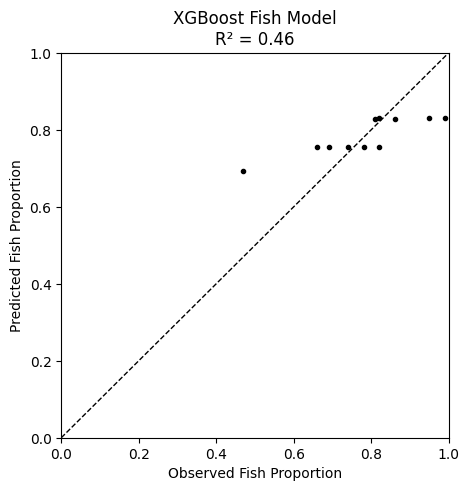

In [25]:
#Step 6: Plot observed vs predicted values

#x-axis = Bayesian mixing-model proportions
#y-axis = XGBoost-predicted proportions
#dashed line = perfect agreement between observed and predicted values

plt.figure(figsize=(5, 5))

plt.plot(y_train, y_pred, "k.")

#1:1 reference line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Observed Fish Proportion")
plt.ylabel("Predicted Fish Proportion")

plt.title(f"XGBoost Fish Model\nR² = {r2_score(y_train, y_pred):.2f}")

plt.show()

#If points fall close to the dashed line, the model predictions are close to the Bayesian mixing-model values
#If points are far from the dashed line, the model is not predicting well
#Because this dataset is still very small, these results should be interpreted as a proof-of-concept

The above graph compares the observed fish diet proportions from the Bayesian mixing model to the fish diet proportions predicted by the XGBoost model. The dashed line represents perfect agreement, meaning points closer to the line are more accurate predictions. Most points are somewhat close to the line, showing that the model was able to learn part of the relationship between stable isotope values and fish contribution to the diet.

The model performed alright, with an R² value of 0.46. This means the model explained about 46% of the variation in fish diet proportions. However, many predictions are clustered around similar values near 0.75–0.83, suggesting the model still struggled to capture the full variation in the dataset. This is likely because the dataset was very small, so the model did not have enough examples to fully learn ecological patterns.

# Test the rest of the prey groups

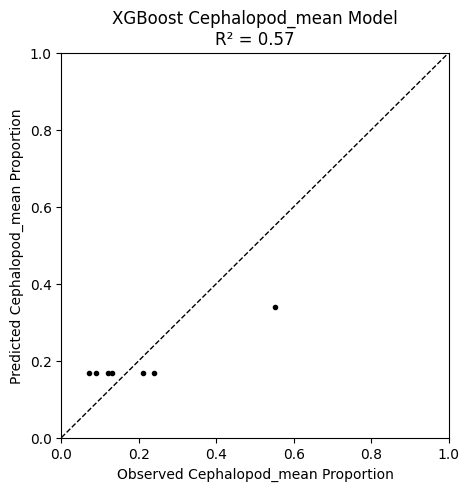

In [27]:
#To test other prey groups change only the "target = " line. For example, you could make it "target = "Cephalopod_mean"" to test the Cephalopod group

#Testing cephalopod contribution

target = "Cephalopod_mean"


#Prepare data for cephalopods

data_for_model = X.copy()
data_for_model[target] = Y[target]

data_for_model = data_for_model.dropna(subset=[target])

X_train = data_for_model.drop(columns=[target])
y_train = data_for_model[target]

X_train = X_train.fillna(X_train.mean())


#Fit XGBoost model

model = xgb.XGBRegressor(
    n_estimators=20,
    learning_rate=0.05,
    max_depth=1,
    random_state=51
)

model.fit(X_train, y_train)


#Predict and graph cephalopod results

y_pred = model.predict(X_train)

plt.figure(figsize=(5, 5))

plt.plot(y_train, y_pred, "k.")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel(f"Observed {target} Proportion")
plt.ylabel(f"Predicted {target} Proportion")

plt.title(f"XGBoost {target} Model\nR² = {r2_score(y_train, y_pred):.2f}")

plt.show()

The cephalopod model worked a little better than some of the other prey-group models, with an R² of 0.57. The model was able to separate the higher cephalopod diet case from the lower ones, so it seems like it picked up on some real patterns in the isotope data. However, a lot of the predicted values were still pretty similar to each other, showing that the model was still struggling to fully capture all of the variation in the dataset.

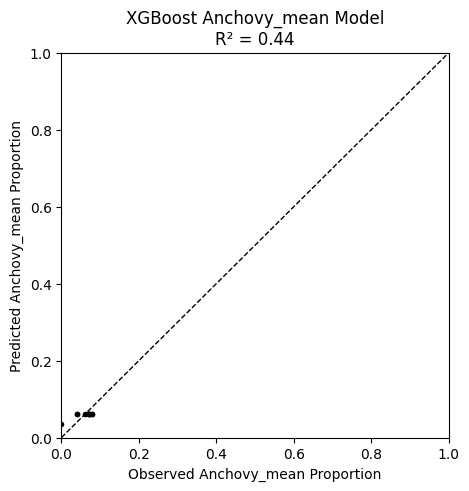

In [28]:
#Testing anchovy contribution

target = "Anchovy_mean"


#Prepare data for anchovy

data_for_model = X.copy()
data_for_model[target] = Y[target]

data_for_model = data_for_model.dropna(subset=[target])

X_train = data_for_model.drop(columns=[target])
y_train = data_for_model[target]

X_train = X_train.fillna(X_train.mean())


#Fit XGBoost model

model = xgb.XGBRegressor(
    n_estimators=20,
    learning_rate=0.05,
    max_depth=1,
    random_state=51
)

model.fit(X_train, y_train)


#Predict and graph anchovy results

y_pred = model.predict(X_train)

plt.figure(figsize=(5, 5))

plt.plot(y_train, y_pred, "k.")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel(f"Observed {target} Proportion")
plt.ylabel(f"Predicted {target} Proportion")

plt.title(f"XGBoost {target} Model\nR² = {r2_score(y_train, y_pred):.2f}")

plt.show()

The anchovy model had moderate performance, with an R² of 0.44. Most of the anchovy proportions were already very low, and the model mostly predicted low values across all samples. This suggests the model recognized that anchovy was generally a small part of the diet, but there was not a lot of variation for it to learn from.

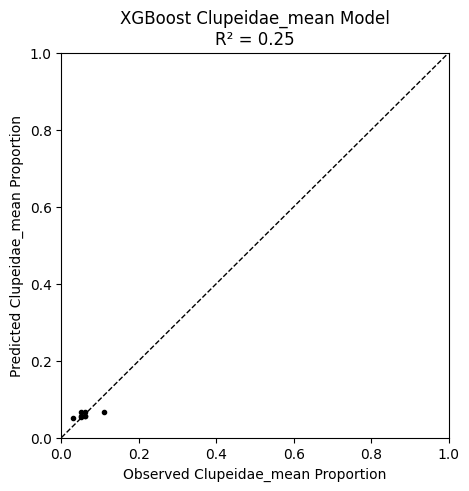

In [29]:
#Testing clupeidae contribution

target = "Clupeidae_mean"


#Prepare data for clupeidae

data_for_model = X.copy()
data_for_model[target] = Y[target]

data_for_model = data_for_model.dropna(subset=[target])

X_train = data_for_model.drop(columns=[target])
y_train = data_for_model[target]

X_train = X_train.fillna(X_train.mean())


#Fit XGBoost model

model = xgb.XGBRegressor(
    n_estimators=20,
    learning_rate=0.05,
    max_depth=1,
    random_state=51
)

model.fit(X_train, y_train)


#Predict and graph clupeidae results

y_pred = model.predict(X_train)

plt.figure(figsize=(5, 5))

plt.plot(y_train, y_pred, "k.")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel(f"Observed {target} Proportion")
plt.ylabel(f"Predicted {target} Proportion")

plt.title(f"XGBoost {target} Model\nR² = {r2_score(y_train, y_pred):.2f}")

plt.show()

The Clupeidae model had the weakest performance, with an R² of 0.25. The predictions were clustered very closely together, meaning the model mostly predicted similar values regardless of the observed proportion. This suggests the isotope data did not strongly explain differences in Clupeidae contribution, or that there was not enough variation and sample size for the model to learn those patterns well.

# Analysis

The XGBoost models showed mixed success at predicting Bayesian mixing-model diet proportions from stable isotope data. Overall, the models performed best for broader prey categories such as total fish contribution and somewhat less well for narrower prey groups such as Clupeidae and anchovies. The fish model produced the strongest overall pattern, with predicted values generally following the trend of the observed Bayesian diet proportions. This suggests that stable isotope values contain ecological information related to dolphin diet, allowing the model to detect some relationship between predator isotopes, prey isotopes, and fish contribution to the diet. The cephalopod model also showed moderate performance, while the anchovy and Clupeidae models performed more poorly, with predictions clustered near similar values across samples. This likely occurred because these prey groups had low variation and small contribution values in the dataset, making it difficult for the model to learn strong isotope-diet relationships.

Several factors likely limited model performance. First, the dataset became very small after dolphin and prey isotope values were averaged by location and year to match the structure of the Bayesian mixing-model outputs. This averaging was necessary because many individual dolphins shared a single group-level diet estimate, which is not ideal for machine learning models that learn best when each row has its own output value. Second, some prey species were only present in certain locations, creating missing values and uneven prey representation across regions. Third, stable isotope signatures can overlap among prey groups, especially within similar trophic levels, reducing the model’s ability to clearly distinguish among prey categories.

Finally, data from multiple geographic regions were combined, even though stable isotope values are generally not directly comparable across ecosystems because baseline isotope signatures differ among regions. Differences in primary production and oceanographic conditions can shift δ¹³C and δ¹⁵N values independently of trophic level. As a result, some of the patterns learned by the model may reflect geographic differences rather than true diet differences. However, combining regions was necessary because modeling regions separately would have left too few rows for the model to train.